# Assignment: Face Clustering with PCA and K-Means

### **Introduction**

In this kernel, we will apply **Principal Component Analysis (PCA)** and **K-Means clustering** to the **Olivetti Face Dataset**, which consists of 400 grayscale images of faces. The goal is to cluster the images based on visual similarities, using PCA to reduce the dimensionality of the dataset and K-Means to group similar faces together.

PCA will be used to compress the high-dimensional face data while retaining 99% of the variance, making it easier for K-Means to perform effective clustering. The performance of the clustering will be visually assessed by examining the faces within each cluster to determine whether the algorithm successfully groups faces with similar characteristics such as pose, expression, and lighting.

The steps involved in this task include:
1. **Loading the dataset** and preparing it for clustering.
2. **Applying PCA** to reduce dimensionality.
3. **Using K-Means** to cluster the data into 120 clusters.
4. **Visualizing the clusters** and evaluating the results.

Through this exercise, we aim to explore the effectiveness of clustering algorithms in recognizing patterns in facial images and understand the impact of dimensionality reduction on the clustering performance.


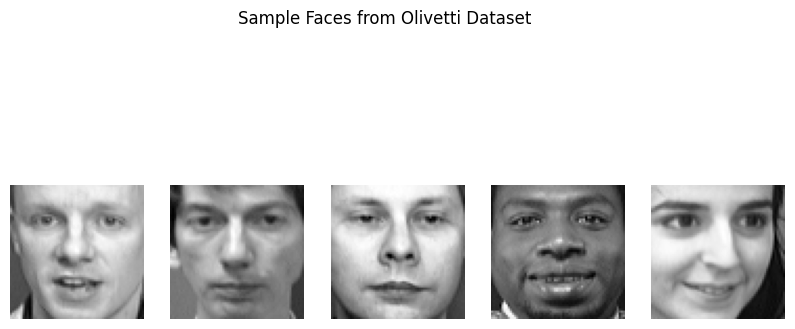

In [7]:
from sklearn.datasets import fetch_olivetti_faces
import matplotlib.pyplot as plt

# Load dataset
data = fetch_olivetti_faces(shuffle=True, random_state=42)
X = data.data   
images = data.images  
targets = data.target  

# Display a few example faces
fig, ax = plt.subplots(1, 5, figsize=(10, 5))
for i in range(5):
    ax[i].imshow(images[i], cmap='gray')
    ax[i].axis('off')
plt.suptitle("Sample Faces from Olivetti Dataset")
plt.show()


In [8]:


labels = data.target

num_labels = len(np.unique(labels))
print(f"Number of unique labels: {num_labels}")


Number of unique labels: 40




Each face image in the Olivetti dataset is a grayscale image of size **64 × 64 pixels**, which equals **4096** total pixels.

- These images are **flattened into 1D vectors** so that each row in the dataset corresponds to a single image.
- This format is useful for feeding into machine learning models like **PCA** or **K-Means**, which expect 2D arrays of shape `(n_samples, n_features)`.

Hence, each row is a **1D vector of length 4096**, representing one face.

---

The dataset includes **40 unique individuals**, and each individual has **10 face images**, resulting in a total of **400 images**.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces


X = data.data
y = data.target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=26
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 280
Testing samples: 120


In [14]:
from sklearn.decomposition import PCA

# Apply PCA to preserve 99% of variance
pca = PCA(n_components=0.99, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# Output dimensions
print("Original training data shape:", X_train.shape)
print("Compressed training data shape:", X_train_pca.shape)
print(f"Number of PCA components retained: {pca.n_components_}")

Original training data shape: (280, 4096)
Compressed training data shape: (280, 198)
Number of PCA components retained: 198




The original training data consists of flattened 64×64 grayscale face images.  
Each image has **4096 features** (64 × 64 = 4096).


---

After applying PCA with `n_components=0.99` (preserving 99% variance), the number of features was reduced to **198**.




In [21]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=120, random_state=26, n_init='auto')
kmeans.fit(X_train_pca)

# Predicted cluster labels
cluster_labels = kmeans.labels_

print("K-Means clustering complete.")
print(f"Number of clusters: {len(set(cluster_labels))}")


K-Means clustering complete.
Number of clusters: 120



Cluster 0


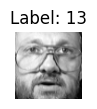


Cluster 1


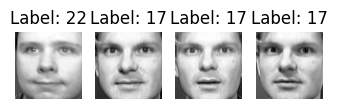


Cluster 2


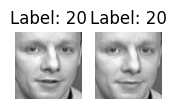


Cluster 3


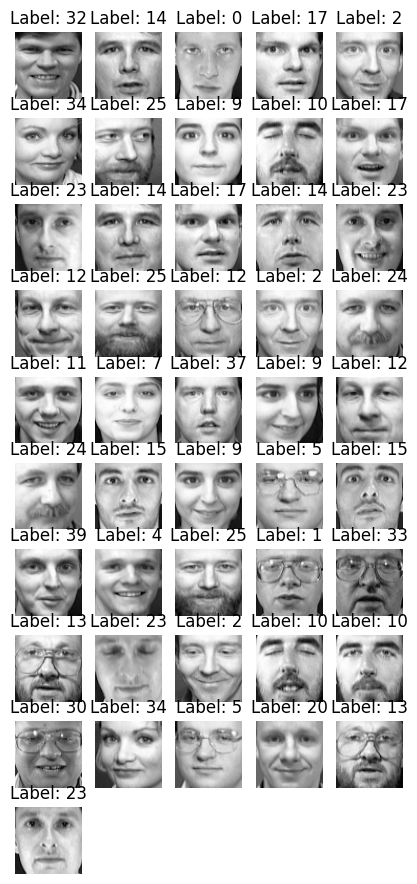


Cluster 4


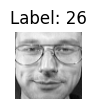


Cluster 5


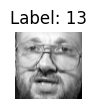


Cluster 6


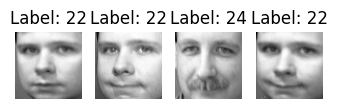


Cluster 7


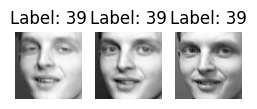


Cluster 8


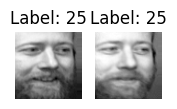


Cluster 9


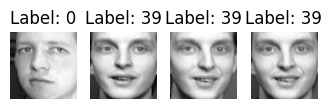


Cluster 10


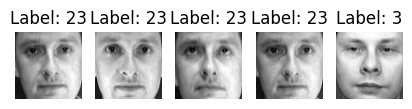


Cluster 11


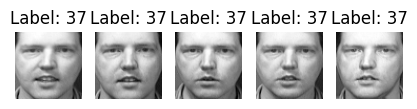


Cluster 12


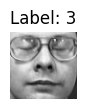


Cluster 13


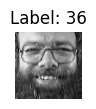


Cluster 14


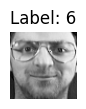


Cluster 15


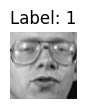


Cluster 16


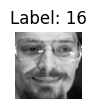


Cluster 17


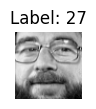


Cluster 18


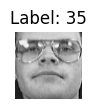


Cluster 19


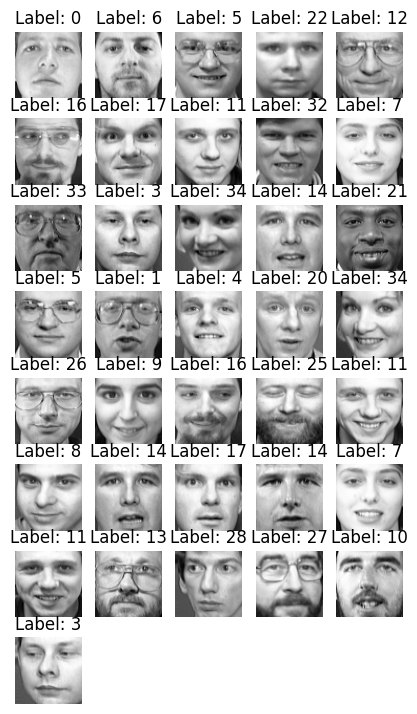


Cluster 20


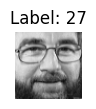


Cluster 21


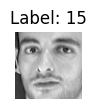


Cluster 22


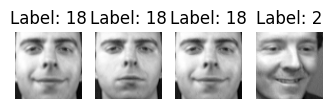


Cluster 23


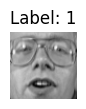


Cluster 24


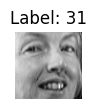


Cluster 25


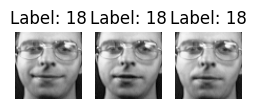


Cluster 26


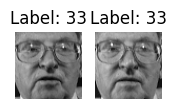


Cluster 27


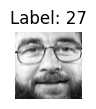


Cluster 28


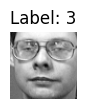


Cluster 29


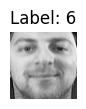


Cluster 30


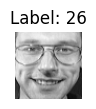


Cluster 31


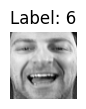


Cluster 32


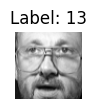


Cluster 33


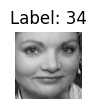


Cluster 34


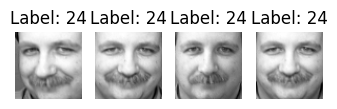


Cluster 35


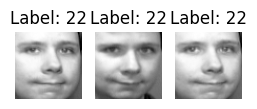


Cluster 36


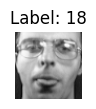


Cluster 37


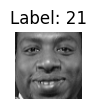


Cluster 38


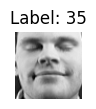


Cluster 39


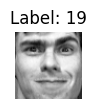


Cluster 40


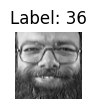


Cluster 41


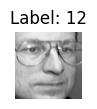


Cluster 42


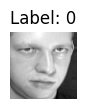


Cluster 43


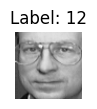


Cluster 44


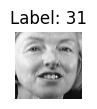


Cluster 45


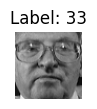


Cluster 46


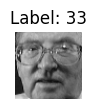


Cluster 47


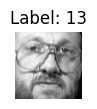


Cluster 48


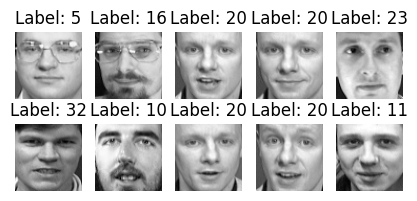


Cluster 49


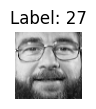


Cluster 50


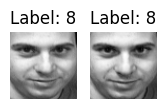


Cluster 51


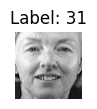


Cluster 52


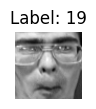


Cluster 53


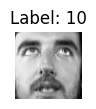


Cluster 54


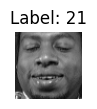


Cluster 55


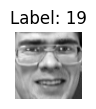


Cluster 56


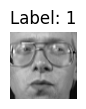


Cluster 57


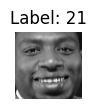


Cluster 58


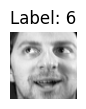


Cluster 59


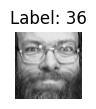


Cluster 60


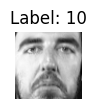


Cluster 61


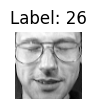


Cluster 62


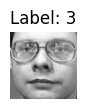


Cluster 63


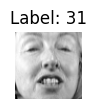


Cluster 64


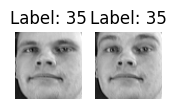


Cluster 65


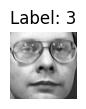


Cluster 66


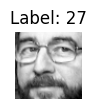


Cluster 67


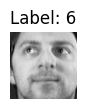


Cluster 68


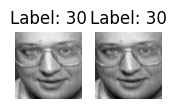


Cluster 69


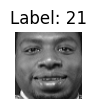


Cluster 70


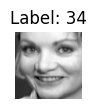


Cluster 71


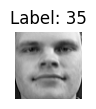


Cluster 72


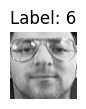


Cluster 73


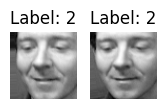


Cluster 74


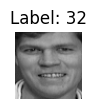


Cluster 75


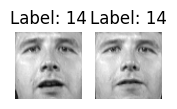


Cluster 76


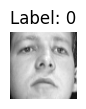


Cluster 77


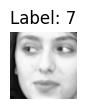


Cluster 78


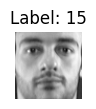


Cluster 79


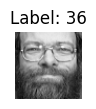


Cluster 80


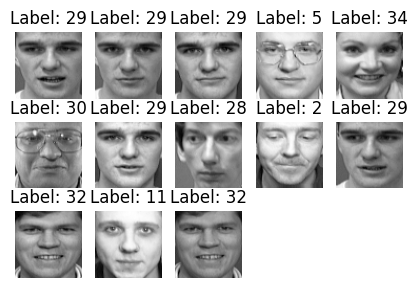


Cluster 81


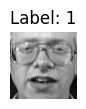


Cluster 82


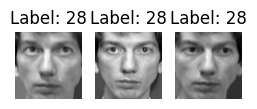


Cluster 83


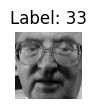


Cluster 84


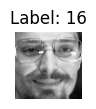


Cluster 85


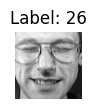


Cluster 86


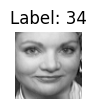


Cluster 87


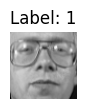


Cluster 88


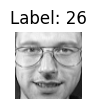


Cluster 89


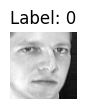


Cluster 90


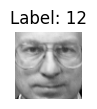


Cluster 91


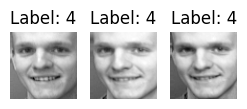


Cluster 92


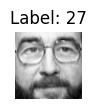


Cluster 93


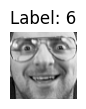


Cluster 94


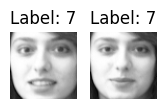


Cluster 95


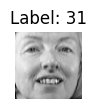


Cluster 96


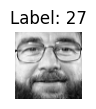


Cluster 97


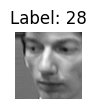


Cluster 98


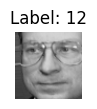


Cluster 99


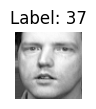


Cluster 100


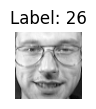


Cluster 101


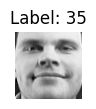


Cluster 102


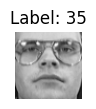


Cluster 103


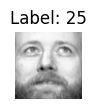


Cluster 104


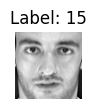


Cluster 105


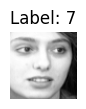


Cluster 106


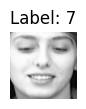


Cluster 107


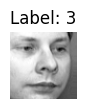


Cluster 108


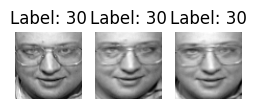


Cluster 109


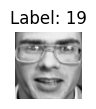


Cluster 110


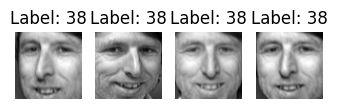


Cluster 111


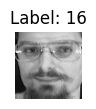


Cluster 112


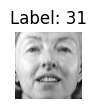


Cluster 113


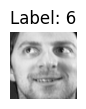


Cluster 114


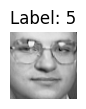


Cluster 115


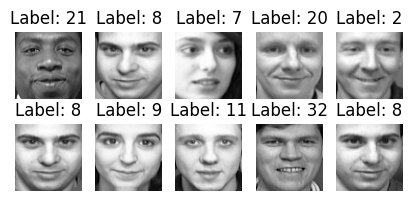


Cluster 116


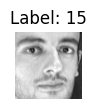


Cluster 117


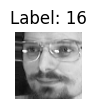


Cluster 118


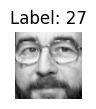


Cluster 119


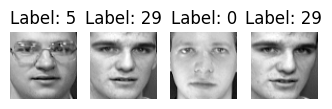

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming plot_faces function is defined already
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(f"Label: {label}")
    plt.show()


# Visualize the faces in each cluster
for cluster_id in np.unique(kmeans.labels_):
    print(f"\nCluster {cluster_id}")

    # Select faces in the current cluster
    in_cluster = kmeans.labels_ == cluster_id
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]

    # Plot the faces and their corresponding labels
    plot_faces(faces, labels)

# Clustering Results Evaluation

### 1. **Clustering Result:**
The K-Means clustering algorithm successfully grouped faces based on **visual similarities**. From the limited clusters examined:

- **Cluster 0:** The algorithm grouped faces with distinct features like **glasses**, which suggests it recognized this prominent characteristic.
- **Cluster 1:** Faces with shared characteristics such as beards and glasses were grouped despite minor differences in pose or lighting.
- **Cluster 2:** The faces in this cluster appear to share a similar **pose**, which shows that K-Means captured both facial features and pose-related patterns.

The faces in each cluster show **visual similarities** based on key features (e.g., glasses, beards, pose). This indicates that K-Means successfully captured groups of faces with similar visual traits.

### 3. **Conclusion:**
- **Strengths:** The clustering effectively groups faces with similar features, which is a positive result.
- **Limitations:** The algorithm may struggle with subtle variations in pose, lighting, and other minor features. Additionally, the number of clusters chosen (120) may impact the clustering quality.

